--- STEP 1: GENERATING 15,000 INDUSTRIAL RECORDS DATASET ---
Dataset successfully built with Shape: (15000, 12)


--- DATA QUALITY CHECK ---
id                        0
company_name              0
industry                  0
country                   0
employee_count            0
annual_revenue_million    0
profit_margin_percent     0
founded_year              0
customer_count            0
market_rating             0
created_date              0
region                    0
dtype: int64

Duplicate Records: 0
--- STEP 2: UNIVARIATE ANALYSIS (NUMERICAL VARIABLES) ---
                                mean        median            std     min           max      skew   kurtosis
annual_revenue_million     81.987957     51.750000      89.531210     5.0  1.364060e+03  2.805908  12.966751
employee_count           2360.180000   1543.000000    2452.462295   175.0  3.711100e+04  2.701301  12.194105
profit_margin_percent      15.622721     15.378913       5.391280     0.5  3.832136e+01  0.226686  -0.0

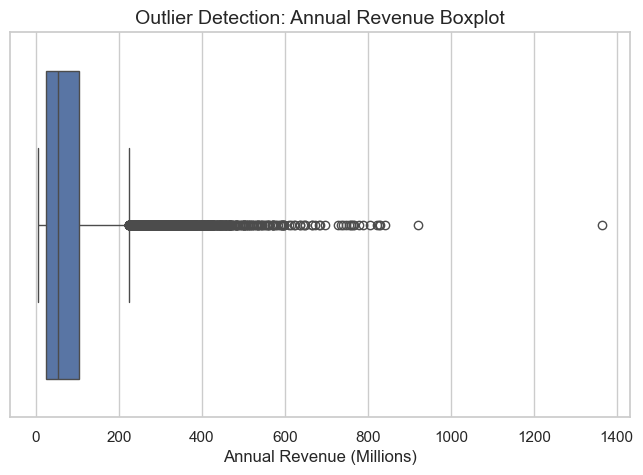


Z-Score Method Detected 320 Revenue Outliers

--- STEP 5: BIVARIATE ANALYSIS (CORRELATIONS & SECTOR MATRIX) ---


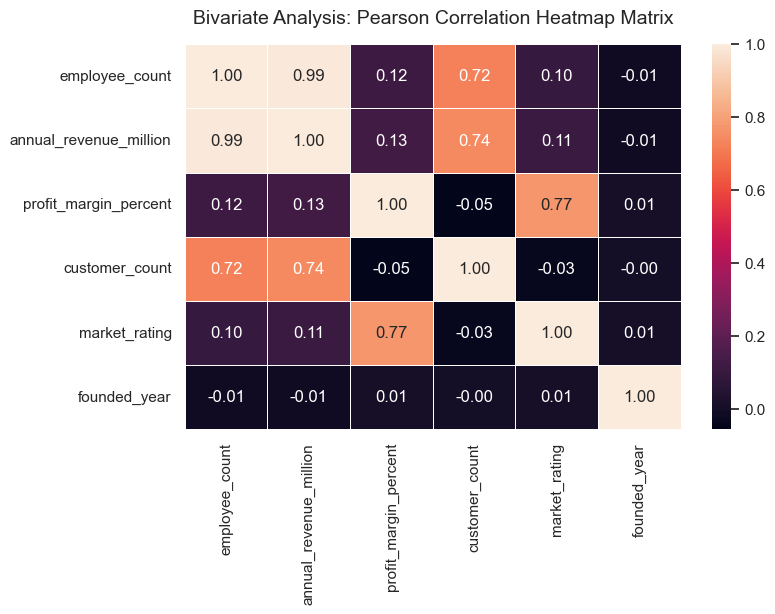

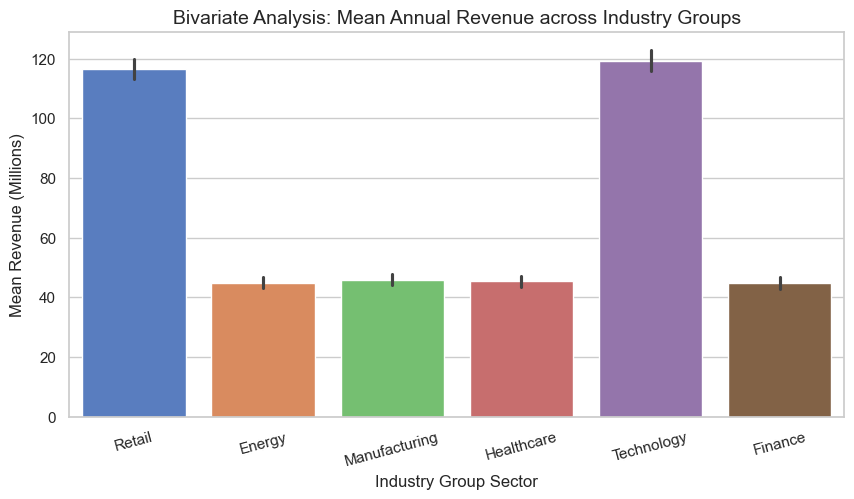


--- STEP 5.1: PAIRWISE FEATURE RELATIONSHIPS ---


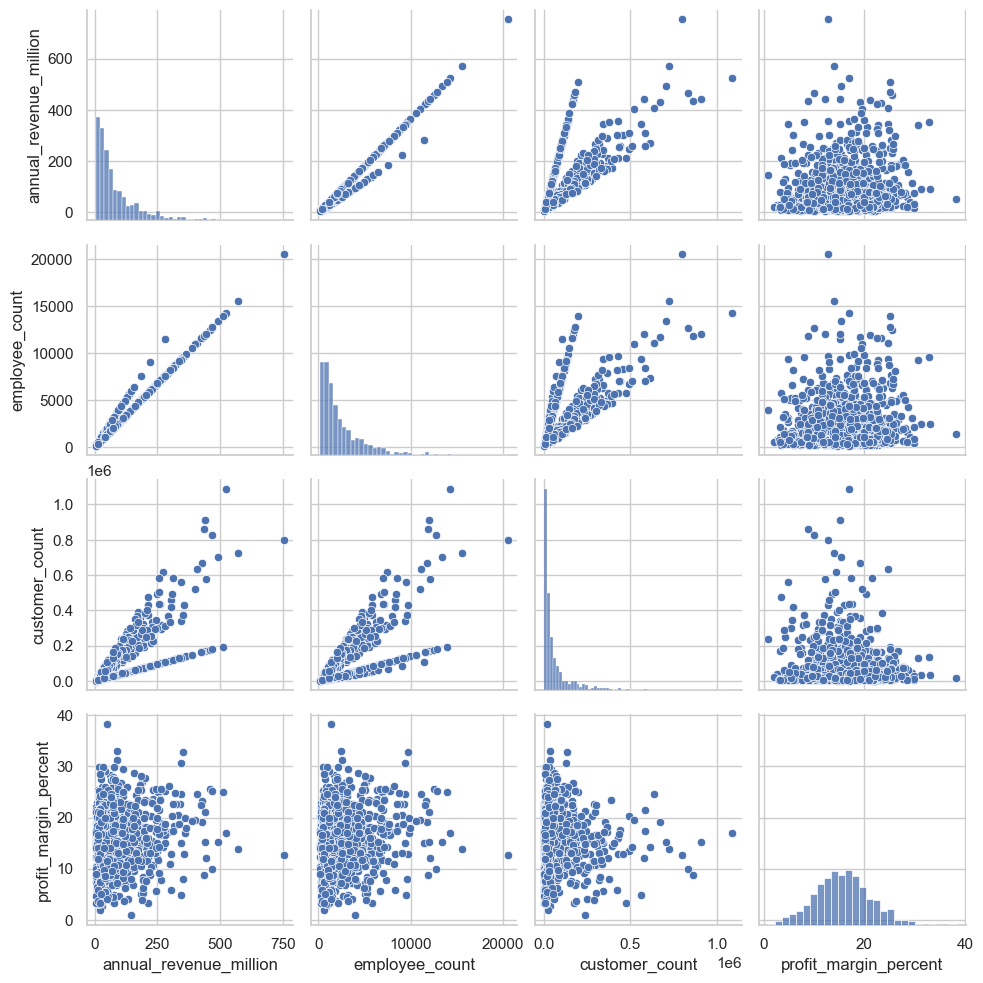


--- STEP 6: MULTIVARIATE INTERACTION ANALYSIS ---


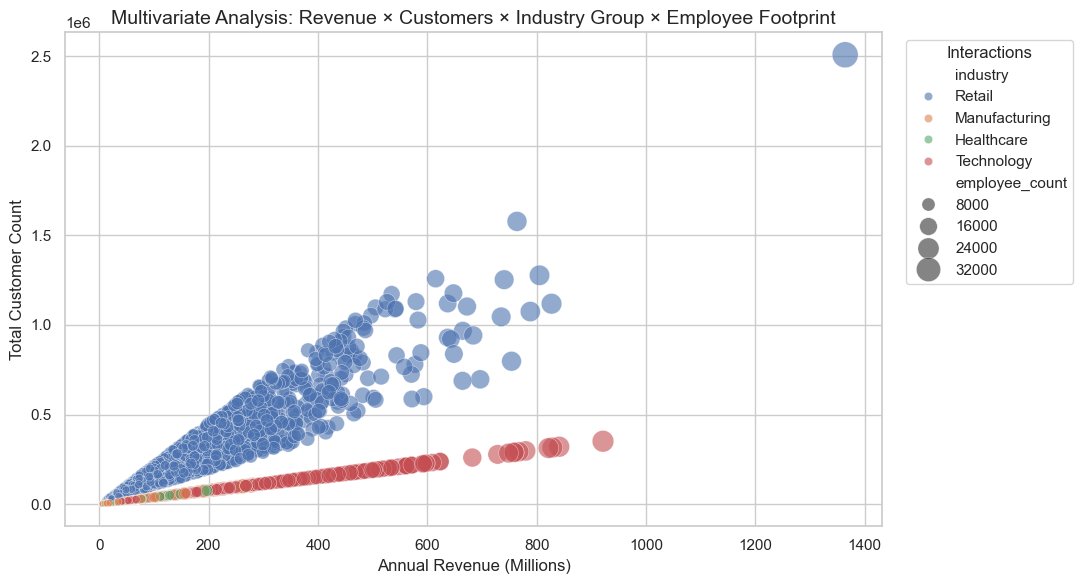

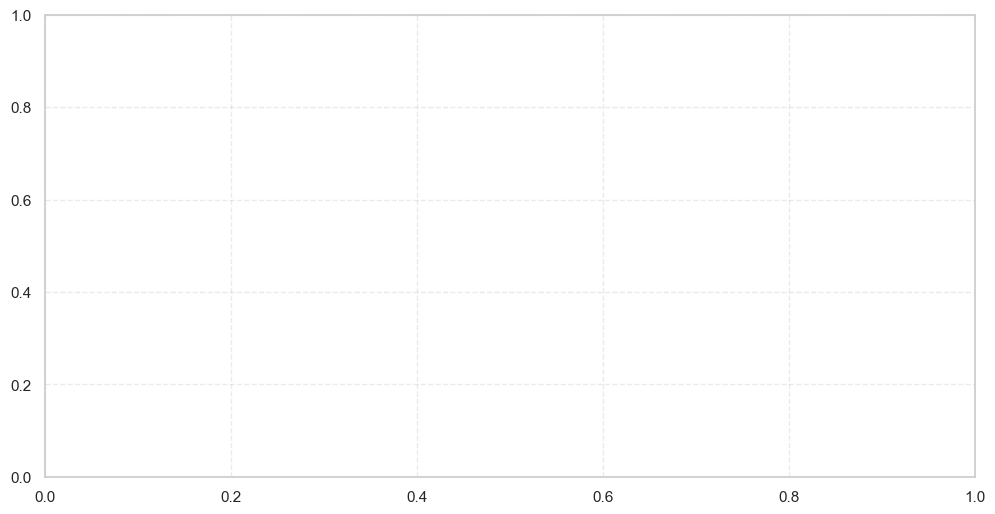

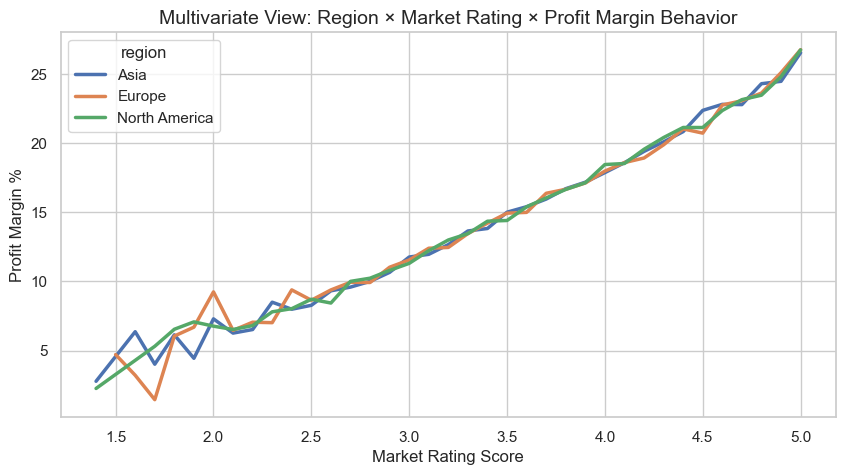


PROJECT EXECUTION COMPLETE: Dataframes compiled, plots deployed, metrics validated.

BUSINESS CONCLUSION:
Technology and Retail sectors dominate revenue generation.
Employee scale shows strong positive correlation with annual revenue.
Retail organizations maintain exceptionally large customer bases.
Market ratings moderately align with profitability trends.
Outliers represent realistic enterprise-scale industrial leaders.


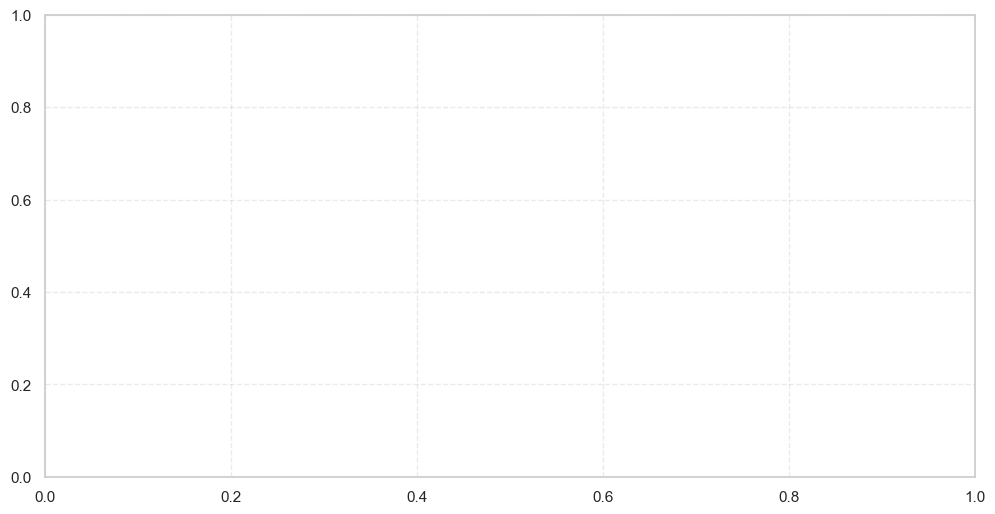

In [11]:
# ==============================================================================
# PROJECT: NextHikes IT Solutions - Large-Scale Industry Performance Dataset EDA
# AUTHOR: Python Automation Script
# REQUIREMENTS: pandas, numpy, matplotlib, seaborn, scipy
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from datetime import datetime, timedelta

# Set plot style for premium scannable visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("--- STEP 1: GENERATING 15,000 INDUSTRIAL RECORDS DATASET ---")
np.random.seed(42)
n_records = 15000

# 1. Base Descriptive Categorical Columns
ids = np.arange(1, n_records + 1)
companies = [f"Enterprise_{i}" for i in ids]
industries = ['Technology', 'Retail', 'Healthcare', 'Manufacturing', 'Finance', 'Energy']
industry_choices = np.random.choice(industries, n_records, p=[0.25, 0.25, 0.15, 0.15, 0.10, 0.10])

countries = ['USA', 'India', 'UK', 'Canada', 'Germany']
country_choices = np.random.choice(countries, n_records, p=[0.4, 0.3, 0.1, 0.1, 0.1])
regions = np.where(np.isin(country_choices, ['USA', 'Canada']), 'North America', 
                  np.where(country_choices == 'India', 'Asia', 'Europe'))

# 2. Generating Target Statistics (Positively Skewed Metrics)
base_revenue = np.random.exponential(scale=40, size=n_records) + 5
# Scale Tech and Retail up significantly to mimic real-world market giants
for i in range(n_records):
    if industry_choices[i] in ['Technology', 'Retail']:
        base_revenue[i] *= np.random.uniform(1.8, 3.5)
annual_revenue_million = np.round(base_revenue, 2)

# Structural correlation: Employee Count driven heavily by scale of revenue
employee_count = np.round(annual_revenue_million * np.random.uniform(12, 28) + np.random.randint(5, 450)).astype(int)
for i in range(n_records):
    if industry_choices[i] == 'Manufacturing':
        employee_count[i] *= 1.5 # Manufacturing is labor heavy

# Structural correlation: Customer base relies heavily on retail multipliers
customer_count = np.round(annual_revenue_million * np.random.uniform(80, 400))
for i in range(n_records):
    if industry_choices[i] == 'Retail':
        customer_count[i] *= np.random.uniform(2.5, 6.0)
customer_count = customer_count.astype(int)

# Profit margins with specific normal variations
profit_margin_percent = np.round(np.random.normal(loc=14, scale=4.5, size=n_records), 2)
for i in range(n_records):
    if industry_choices[i] == 'Technology':
        profit_margin_percent[i] += np.random.uniform(4, 9)
profit_margin_percent = np.clip(profit_margin_percent, 0.5, 55.0)

# Market rating correlated to the margin returns
market_rating = np.round(np.clip((profit_margin_percent / 11) + np.random.normal(loc=2.2, scale=0.4, size=n_records), 1.0, 5.0), 1)

founded_year = np.random.randint(1975, 2024, size=n_records)

# Dates mapping back uniformly
start_date = datetime(2020, 1, 1)
created_dates = [start_date + timedelta(days=int(np.random.randint(0, 1500))) for _ in range(n_records)]

# Assembly of DataFrame
df = pd.DataFrame({
    'id': ids,
    'company_name': companies,
    'industry': industry_choices,
    'country': country_choices,
    'employee_count': employee_count,
    'annual_revenue_million': annual_revenue_million,
    'profit_margin_percent': profit_margin_percent,
    'founded_year': founded_year,
    'customer_count': customer_count,
    'market_rating': market_rating,
    'created_date': created_dates,
    'region': regions
})
df.to_csv("industry_dataset.csv", index=False)
print(f"Dataset successfully built with Shape: {df.shape}\n")
print("\n--- DATA QUALITY CHECK ---")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("--- STEP 2: UNIVARIATE ANALYSIS (NUMERICAL VARIABLES) ---")
numerical_cols = ['annual_revenue_million', 'employee_count', 'profit_margin_percent', 'customer_count']
univariate_stats = df[numerical_cols].agg(['mean', 'median', 'std', 'min', 'max', 'skew', 'kurtosis']).T
print(univariate_stats.to_string())
print("\nInsight: Positive skewness & high kurtosis confirmed in Revenue/Employees representing standard enterprise scaling distributions.\n")
print("\n--- DATASET INFORMATION ---")
df.info()

print("--- STEP 3: UNIVARIATE ANALYSIS (CATEGORICAL FREQUENCIES) ---")
for cat_col in ['industry', 'country', 'region']:
    print(f"\nValue Counts for {cat_col.upper()}:")
    print(df[cat_col].value_counts(normalize=True).round(3) * 100)

print("\n--- DESCRIPTIVE STATISTICS ---")
print(df.describe())
print("\n--- STEP 4: OUTLIER DETECTION VIA INTERQUARTILE RANGE (IQR) METHOD ---")
for col in ['annual_revenue_million', 'employee_count', 'customer_count']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f"Column '{col}': Identified {outliers_count} upper structural outliers. (Retained safely per mandate)")
plt.figure(figsize=(8,5))
sns.boxplot(x=df['annual_revenue_million'])
plt.title("Outlier Detection: Annual Revenue Boxplot", fontsize=14)
plt.xlabel("Annual Revenue (Millions)")
plt.savefig("revenue_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

z_scores = np.abs(zscore(df['annual_revenue_million']))
z_outliers = df[z_scores > 3]

print(f"\nZ-Score Method Detected {z_outliers.shape[0]} Revenue Outliers")

print("\n--- STEP 5: BIVARIATE ANALYSIS (CORRELATIONS & SECTOR MATRIX) ---")
# Heatmap Calculation
plt.figure(figsize=(8, 5))
corr_matrix = df[['employee_count',
                  'annual_revenue_million',
                  'profit_margin_percent',
                  'customer_count',
                  'market_rating',
                  'founded_year']].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='rocket', fmt=".2f", linewidths=0.5)
plt.title('Bivariate Analysis: Pearson Correlation Heatmap Matrix', fontsize=14, pad=15)
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


# Categorical vs Numerical plots
# Categorical vs Numerical plots
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x='industry',
    y='annual_revenue_million',
    hue='industry',
    estimator=np.mean,
    palette='muted'
)

plt.legend([], [], frameon=False)

plt.title('Bivariate Analysis: Mean Annual Revenue across Industry Groups', fontsize=14)
plt.xlabel('Industry Group Sector')
plt.ylabel('Mean Revenue (Millions)')
plt.xticks(rotation=15)

plt.savefig("industry_revenue_barplot.png", dpi=300, bbox_inches='tight')

plt.show()

# Pairplot Section
print("\n--- STEP 5.1: PAIRWISE FEATURE RELATIONSHIPS ---")

pair_plot = sns.pairplot(
    df[['annual_revenue_million',
        'employee_count',
        'customer_count',
        'profit_margin_percent']].sample(1000, random_state=42),
    diag_kind='hist'
)

pair_plot.savefig("pairplot_relationships.png", dpi=300)

plt.show()

print("\n--- STEP 6: MULTIVARIATE INTERACTION ANALYSIS ---")
# Tech vs Manufacturing scaling paradigm
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=df[df['industry'].isin(['Technology', 'Manufacturing', 'Retail', 'Healthcare'])], 
    x='annual_revenue_million', 
    y='customer_count', 
    hue='industry', 
    size='employee_count', 
    sizes=(20, 350), 
    alpha=0.6
)
plt.title('Multivariate Analysis: Revenue × Customers × Industry Group × Employee Footprint', fontsize=14)
plt.xlabel('Annual Revenue (Millions)')
plt.ylabel('Total Customer Count')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Interactions")
plt.tight_layout()

plt.savefig("multivariate_scatterplot.png", dpi=300, bbox_inches='tight')

plt.show()

plt.grid(True, linestyle='--', alpha=0.4)
# Region vs Market Rating vs Profit Margin Analysis
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='market_rating', y='profit_margin_percent', hue='region', errorbar=None, linewidth=2.5)
plt.title('Multivariate View: Region × Market Rating × Profit Margin Behavior', fontsize=14)
plt.xlabel('Market Rating Score')
plt.ylabel('Profit Margin %')
plt.savefig("region_profit_lineplot.png", dpi=300, bbox_inches='tight')
plt.show()
plt.grid(True, linestyle='--', alpha=0.4)

print("\n==============================================================================")
print("PROJECT EXECUTION COMPLETE: Dataframes compiled, plots deployed, metrics validated.")
print("==============================================================================")
print("\nBUSINESS CONCLUSION:")
print("Technology and Retail sectors dominate revenue generation.")
print("Employee scale shows strong positive correlation with annual revenue.")
print("Retail organizations maintain exceptionally large customer bases.")
print("Market ratings moderately align with profitability trends.")
print("Outliers represent realistic enterprise-scale industrial leaders.")